In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import (
    train_test_split, cross_val_score, learning_curve,GridSearchCV
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)

In [3]:
df = pd.read_csv("ames_cleaned.csv")

In [4]:
df.head()

,Lot Frontage,Lot Area,Lot Shape,Land Slope,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,Exter Qual,...,Mo Sold_3,Mo Sold_4,Mo Sold_5,Mo Sold_6,Mo Sold_7,Mo Sold_8,Mo Sold_9,Mo Sold_10,Mo Sold_11,Mo Sold_12
0,141.0,31770,3,1,6,5,1960,1960,112.0,3,...,0,0,1,0,0,0,0,0,0,0
1,80.0,11622,4,1,5,6,1961,1961,0.0,3,...,0,0,0,1,0,0,0,0,0,0
2,81.0,14267,3,1,6,6,1958,1958,108.0,3,...,0,0,0,1,0,0,0,0,0,0
3,93.0,11160,4,1,7,5,1968,1968,0.0,4,...,0,1,0,0,0,0,0,0,0,0
4,74.0,13830,3,1,5,5,1997,1998,0.0,3,...,1,0,0,0,0,0,0,0,0,0


In [5]:
# Since i am trying to predict the sale price , i sepeare X and Y accordingly

In [6]:
X = df.drop(columns=['SalePrice']) ## includes everything except the target (Input variables)
y = df['SalePrice'] # output or the target

In [7]:
df.shape

(2927, 237)

In [8]:
y.describe()

count    2927.000000
mean       12.020918
std         0.407783
min         9.456419
25%        11.771444
50%        11.982935
75%        12.271397
max        13.534474
Name: SalePrice, dtype: float64

## Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
X_train.shape[0]

2341

In [11]:
X_test.shape[0]

586

## Training a decision Tree

In [12]:
dt = DecisionTreeRegressor(
    max_depth=5, # max level is 5
    min_samples_split=20,  # atleast 20 data points are needed to split a node 
    min_samples_leaf=10, # min samples required in a leaf node 
    random_state=42 ## same data used across training 
)

In [13]:
dt.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_le

In [14]:
y_pred_train = dt.predict(X_train)
y_pred_test  = dt.predict(X_test)

## Eval Scores

In [15]:
mae_train  = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train   = r2_score(y_train, y_pred_train)
mse_train = mean_squared_error(y_train,y_pred_train)

In [16]:
mae_test   = mean_absolute_error(y_test, y_pred_test)
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test    = r2_score(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)

In [17]:
cv_scores  = cross_val_score( ## different train test split is used 
    DecisionTreeRegressor(max_depth=8, min_samples_split=10,
                          min_samples_leaf=10, ccp_alpha=0.0, random_state=42),
    X_train, y_train, cv=5, scoring='r2'
)

In [18]:
print("\nMODEL SCORES")
print(f"  Train  | MAE: {mae_train:.4f} | RMSE: {rmse_train:.4f} | R²: {r2_train:.4f} | MSE :{mse_train:.4f}")
print(f"  Test   | MAE: {mae_test:.4f} | RMSE: {rmse_test:.4f} | R²: {r2_test:.4f} | MSE :{mse_test:.4f}")
print(f"  CV R²  | Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")



MODEL SCORES
  Train  | MAE: 0.1226 | RMSE: 0.1681 | R²: 0.8265 | MSE :0.0283
  Test   | MAE: 0.1366 | RMSE: 0.1847 | R²: 0.8100 | MSE :0.0341
  CV R²  | Mean: 0.7935 | Std: 0.0068


## Imprpving Scores

In [19]:
baseline = DecisionTreeRegressor(
    max_depth=5, min_samples_split=20,
    min_samples_leaf=10, random_state=42
)

In [20]:
baseline.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_le

In [21]:
base_r2_train = r2_score(y_train, baseline.predict(X_train))
base_r2_test  = r2_score(y_test,  baseline.predict(X_test))
base_mae      = mean_absolute_error(y_test, baseline.predict(X_test))
base_rmse     = np.sqrt(mean_squared_error(y_test, baseline.predict(X_test)))

In [22]:
print(f"  Train R²  : {base_r2_train:.4f}")
print(f"  Test  R²  : {base_r2_test:.4f}")
print(f"  Test  MAE : {base_mae:.4f}")
print(f"  Test  RMSE: {base_rmse:.4f}")

  Train R²  : 0.8265
  Test  R²  : 0.8100
  Test  MAE : 0.1366
  Test  RMSE: 0.1847


## Hyperparam Tuning

In [23]:
param_grid = {
    'max_depth'        : [4, 5, 6, 7, 8],
    'min_samples_split': [10, 20, 30, 50],
    'min_samples_leaf' : [5, 10, 15, 20],
    'ccp_alpha'        : [0.0, 0.001, 0.005, 0.01]
}

In [24]:
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid, # grid search cv template i created before 
    cv=5, # model trained and tested 5 times
    scoring='r2', # uses r2 to find out the scores
    n_jobs=-1, # using all cpu cores 
    verbose=1 ## we r seeing the progress along with the tuning
)

In [25]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 320 candidates, totalling 1600 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': [0.0, 0.001, ...], 'max_depth': [4, 5, ...], 'min_samples_leaf': [5, 10, ...], 'min_samples_split': [10, 20, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and para

In [26]:
print("\n GRIDSEARCH RESULTS ")
print("Best Parameters :", grid_search.best_params_)
print("Best CV R²      :", round(grid_search.best_score_, 4))


 GRIDSEARCH RESULTS 
Best Parameters : {'ccp_alpha': 0.0, 'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 10}
Best CV R²      : 0.7935


## Best Tuned model

In [27]:
best_dt = grid_search.best_estimator_
 
y_pred_train = best_dt.predict(X_train)
y_pred_test  = best_dt.predict(X_test)

In [28]:
mae_train  = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train   = r2_score(y_train, y_pred_train)

In [29]:
mae_test   = mean_absolute_error(y_test, y_pred_test)
rmse_test  = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test    = r2_score(y_test, y_pred_test)

In [30]:
print("\nTUNED MODEL SCORES ")
print(f"  Train  | MAE: {mae_train:.4f} | RMSE: {rmse_train:.4f} | R²: {r2_train:.4f}")
print(f"  Test   | MAE: {mae_test:.4f} | RMSE: {rmse_test:.4f} | R²: {r2_test:.4f}")
print(f"  CV R²  | Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")
print(f"\n  Improvement over baseline:")
print(f"    R² : {base_r2_test:.4f} → {r2_test:.4f}  (+{r2_test - base_r2_test:.4f})")
print(f"    MAE: {base_mae:.4f} → {mae_test:.4f}  ({base_mae - mae_test:+.4f})")


TUNED MODEL SCORES 
  Train  | MAE: 0.0915 | RMSE: 0.1302 | R²: 0.8959
  Test   | MAE: 0.1243 | RMSE: 0.1735 | R²: 0.8324
  CV R²  | Mean: 0.7935 | Std: 0.0068

  Improvement over baseline:
    R² : 0.8100 → 0.8324  (+0.0223)
    MAE: 0.1366 → 0.1243  (+0.0124)


In [33]:
residuals_test  = y_test  - y_pred_test
print("Residuals (Test Set) Summary:")
print(f"  Mean   : {residuals_test.mean():.4f}")
print(f"  Std Dev: {residuals_test.std():.4f}")
print(f"  Min    : {residuals_test.min():.4f}")
print(f"  Max    : {residuals_test.max():.4f}")


Residuals (Test Set) Summary:
  Mean   : -0.0014
  Std Dev: 0.1736
  Min    : -0.8774
  Max    : 0.8433


In [35]:
from scipy import stats

THRESHOLD = 3

anomaly_df = pd.DataFrame({
    'Actual'   : y_test.values,
    'Predicted': y_pred_test,
    'Residual' : residuals_test.values
}, index=y_test.index)

## Z-score calculation

In [36]:
anomaly_df['Z_Score'] = np.abs(stats.zscore(anomaly_df['Residual']))

## IQR

In [37]:
Q1, Q3 = anomaly_df['Residual'].quantile([0.25, 0.75])
IQR = Q3 - Q1
anomaly_df['Is_Anomaly'] = (anomaly_df['Z_Score'] > THRESHOLD) | \
                            (anomaly_df['Residual'] < Q1 - 1.5*IQR) | \
                            (anomaly_df['Residual'] > Q3 + 1.5*IQR)

In [38]:
print(f"Anomalies found: {anomaly_df['Is_Anomaly'].sum()} / {len(anomaly_df)}")
print(anomaly_df[anomaly_df['Is_Anomaly']].sort_values('Z_Score', ascending=False))


Anomalies found: 29 / 586
         Actual  Predicted  Residual   Z_Score  Is_Anomaly
790   11.002117  11.879496 -0.877379  5.048652        True
2858  11.831386  10.988119  0.843267  4.868581        True
940   11.719948  12.457580 -0.737632  4.243194        True
2658  11.277216  11.964609 -0.687393  3.953637        True
695   11.104972  11.774978 -0.670006  3.853419        True
1289  11.066654  11.688332 -0.621678  3.574875        True
2044  12.208575  11.670037  0.538537  3.112220        True
942   11.350418  11.864874 -0.514456  2.956883        True
2238  11.128806  10.630370  0.498436  2.881089        True
1771  12.971543  12.479527  0.492016  2.844085        True
1392  12.367345  11.879496  0.487849  2.820071        True
1220  10.859018  11.343493 -0.484474  2.784078        True
700   11.456895  10.988119  0.468775  2.710135        True
767   11.050906  11.518083 -0.467177  2.684380        True
2657  11.951187  12.390646 -0.439459  2.524625        True
2216  12.466516  12.057246  0.

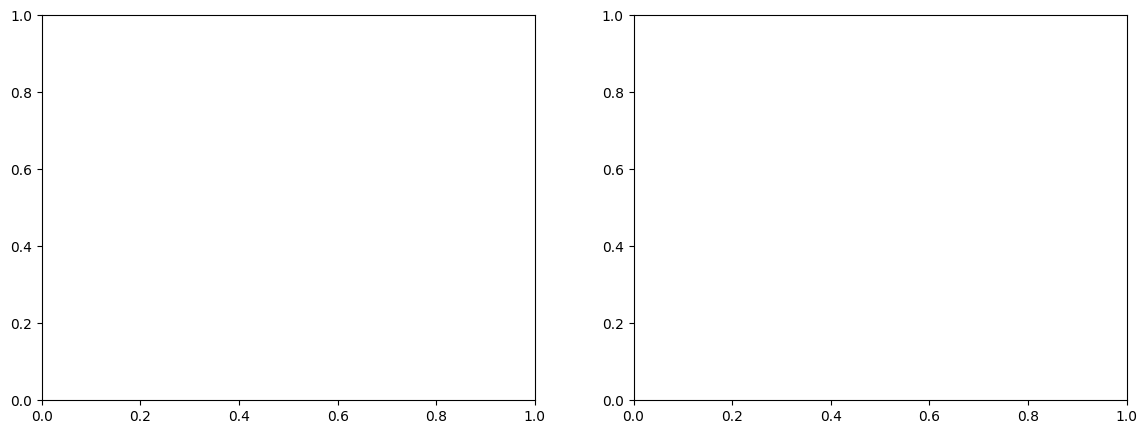

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = anomaly_df['Is_Anomaly'].map({True: 'red', False: 'steelblue'})


Text(4.444444444444452, 0.5, 'Residual')